# Tutorial A05 — Time Series Continuity Check

**Dataset**: `17MPU_ASCENDING` (Ecuador, 11-tile hARDCp run)

**Steps**:
1. Open the Zarr store and inspect all band names and shapes
2. Sample a center pixel and plot all bands as time series
3. Compute NaN statistics per band across the full spatial extent
4. Diagnose the root cause of GLCM discontinuities

In [1]:
# =============================================================================
# Cell 02 — Configuration
# =============================================================================
ZARR_PATH = r"D:\QGIS\s1grits-dataset\Ecuador_Dong_11tiles_ASCENDING_hARDCp\17MPU_ASCENDING\zarr\S1_monthly.zarr"

# Pixel to sample for time series (row, col) — None = auto center
SAMPLE_PIXEL = None

# Additional pixels to compare (list of (row, col) tuples)
# Useful to check if NaN pattern is pixel-specific or global
EXTRA_PIXELS = []  # e.g. [(100, 100), (200, 300)]

In [2]:
# =============================================================================
# Cell 03 — Open Zarr and inspect structure
# =============================================================================
import zarr
import numpy as np
import pandas as pd

z = zarr.open(ZARR_PATH, mode="r")

print("=== Zarr Store Structure ===")
band_keys = []
for k in sorted(z.keys()):
    arr = z[k]
    print(f"  {k:40s} shape={arr.shape}  dtype={arr.dtype}")
    if arr.ndim == 3:
        band_keys.append(k)

# Parse time axis
if "time" in z:
    raw_times = z["time"][:]
    # Try to parse as datetime strings or numeric
    try:
        times = pd.to_datetime(raw_times)
    except Exception:
        times = pd.RangeIndex(len(raw_times))
    print(f"\nTime steps: {len(times)}  ({times[0]} ... {times[-1]})")
else:
    n_time = z[band_keys[0]].shape[0] if band_keys else 0
    times = pd.RangeIndex(n_time)
    print(f"\nNo 'time' key found. Using index 0..{n_time-1}")

print(f"\n3-D band keys ({len(band_keys)}): {band_keys}")

=== Zarr Store Structure ===
  RVI                                      shape=(115, 3661, 3661)  dtype=float32
  Ratio                                    shape=(115, 3661, 3661)  dtype=float32
  VH_dB                                    shape=(115, 3661, 3661)  dtype=float32
  VH_glcm_CONTR                            shape=(115, 3661, 3661)  dtype=float32
  VH_glcm_CORR                             shape=(115, 3661, 3661)  dtype=float32
  VH_glcm_ENT                              shape=(115, 3661, 3661)  dtype=float32
  VH_glcm_IDM                              shape=(115, 3661, 3661)  dtype=float32
  VV_dB                                    shape=(115, 3661, 3661)  dtype=float32
  VV_glcm_CONTR                            shape=(115, 3661, 3661)  dtype=float32
  VV_glcm_CORR                             shape=(115, 3661, 3661)  dtype=float32
  VV_glcm_ENT                              shape=(115, 3661, 3661)  dtype=float32
  VV_glcm_IDM                              shape=(115, 3661, 3661)  d

In [3]:
# =============================================================================
# Cell 04 — NaN statistics per band (full spatial extent)
# =============================================================================
print(f"{'Band':40s} {'NaN%':>7s}  {'min':>10s}  {'max':>10s}  {'mean':>10s}")
print("-" * 85)

nan_stats = {}
for k in sorted(band_keys):
    arr = z[k][:].astype(np.float32)          # load full array (time, y, x)
    arr = np.where(arr < -9998.0, np.nan, arr) # -9999 -> NaN
    total = arr.size
    n_nan = int(np.sum(np.isnan(arr)))
    pct   = 100.0 * n_nan / total
    vmin  = float(np.nanmin(arr)) if n_nan < total else float("nan")
    vmax  = float(np.nanmax(arr)) if n_nan < total else float("nan")
    vmean = float(np.nanmean(arr)) if n_nan < total else float("nan")
    nan_stats[k] = pct
    print(f"  {k:38s} {pct:6.1f}%  {vmin:10.4f}  {vmax:10.4f}  {vmean:10.4f}")

print()
# Separate core bands vs GLCM bands
core_bands = [k for k in band_keys if not "glcm" in k.lower()]
glcm_bands = [k for k in band_keys if "glcm" in k.lower()]
print(f"Core bands: {core_bands}")
print(f"GLCM bands: {glcm_bands}")

Band                                        NaN%         min         max        mean
-------------------------------------------------------------------------------------
  RVI                                       0.1%      0.0017      3.1269      0.7245
  Ratio                                     0.1%      0.0004      3.5814      0.2229
  VH_dB                                     0.1%    -54.4733     -2.2616    -14.5450
  VH_glcm_CONTR                             0.1%      0.0000     16.9833      0.1358
  VH_glcm_CORR                              0.1%     -0.8672      1.0000      0.3370
  VH_glcm_ENT                               0.1%     -0.0000      3.1911      0.5911
  VH_glcm_IDM                               0.1%      0.2710      1.0000      0.9397
  VV_dB                                     0.1%    -30.4639     -0.4981     -7.9272
  VV_glcm_CONTR                             0.1%      0.0000     11.6333      0.1191
  VV_glcm_CORR                              0.1%     -0.9241    

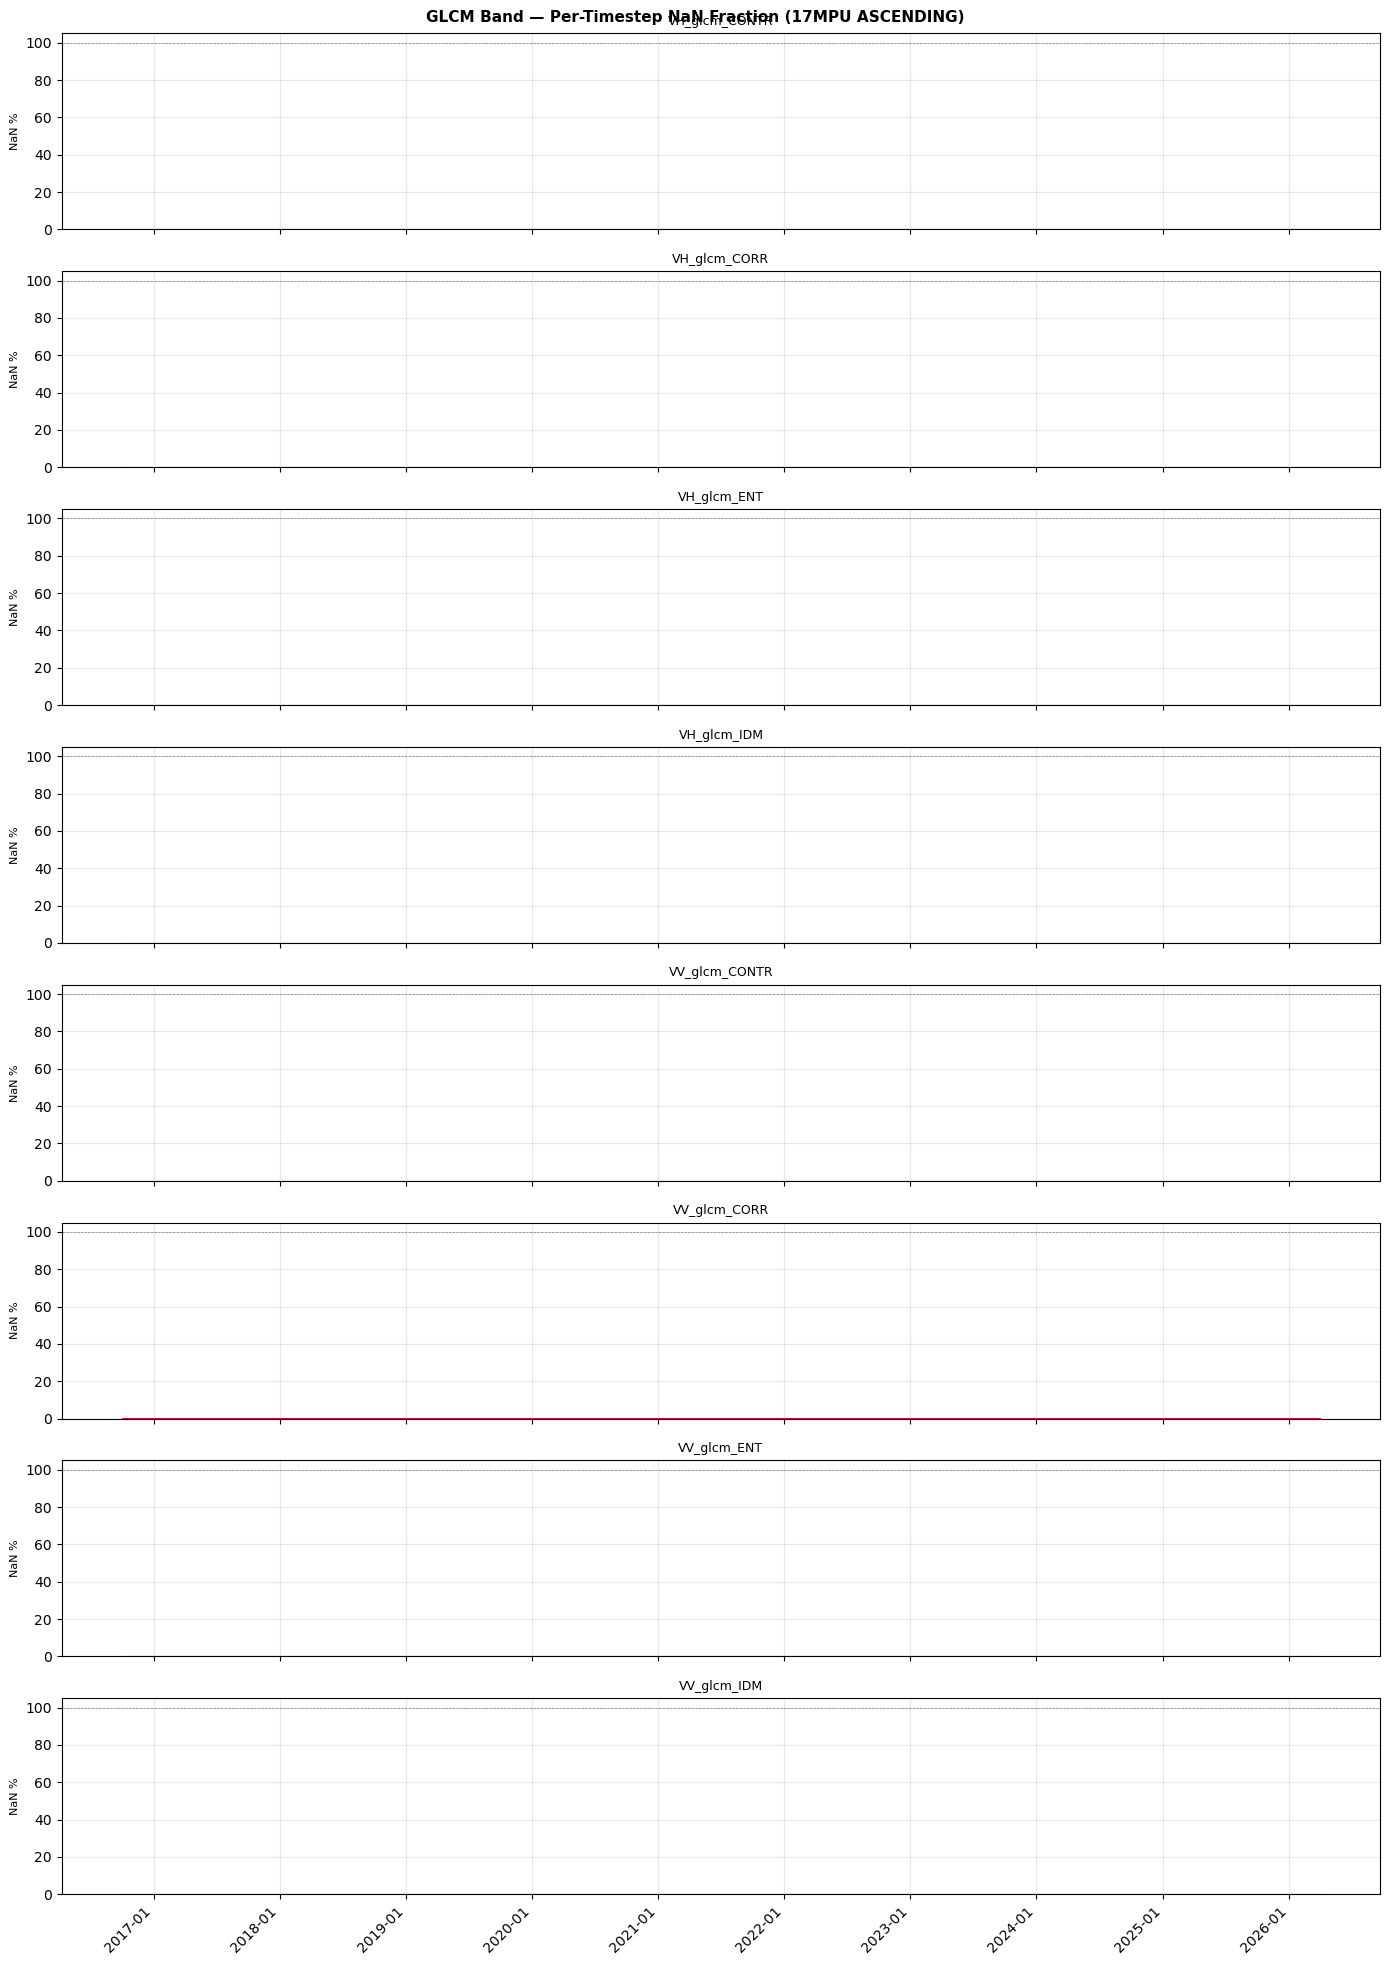

In [4]:
# =============================================================================
# Cell 05 — Per-timestep NaN fraction (are some months entirely NaN for GLCM?)
# =============================================================================
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

if not glcm_bands:
    print("INFO - No GLCM bands found in this Zarr store.")
    print("       GLCM texture features may not have been enabled during processing.")
else:
    # For each GLCM band, compute per-timestep NaN fraction
    fig, axes = plt.subplots(len(glcm_bands), 1,
                             figsize=(14, 2.5 * len(glcm_bands)),
                             sharex=True)
    if len(glcm_bands) == 1:
        axes = [axes]

    for ax, k in zip(axes, sorted(glcm_bands)):
        arr = z[k][:].astype(np.float32)
        arr = np.where(arr < -9998.0, np.nan, arr)
        # NaN fraction per time step
        nan_frac = np.mean(np.isnan(arr), axis=(1, 2))  # shape: (time,)
        ax.plot(times, nan_frac * 100, color="crimson", linewidth=0.8)
        ax.set_ylabel("NaN %", fontsize=8)
        ax.set_title(k, fontsize=9)
        ax.set_ylim(0, 105)
        ax.axhline(100, color="gray", linestyle="--", linewidth=0.5)
        ax.grid(True, alpha=0.3)

    if hasattr(times, 'dtype') and np.issubdtype(times.dtype, np.datetime64):
        axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
        axes[-1].xaxis.set_major_locator(mdates.YearLocator())
        plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=45, ha="right")

    fig.suptitle("GLCM Band — Per-Timestep NaN Fraction (17MPU ASCENDING)",
                 fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.show()

INFO - Sampling pixel: row=1830, col=1830  (array shape: (115, 3661, 3661))


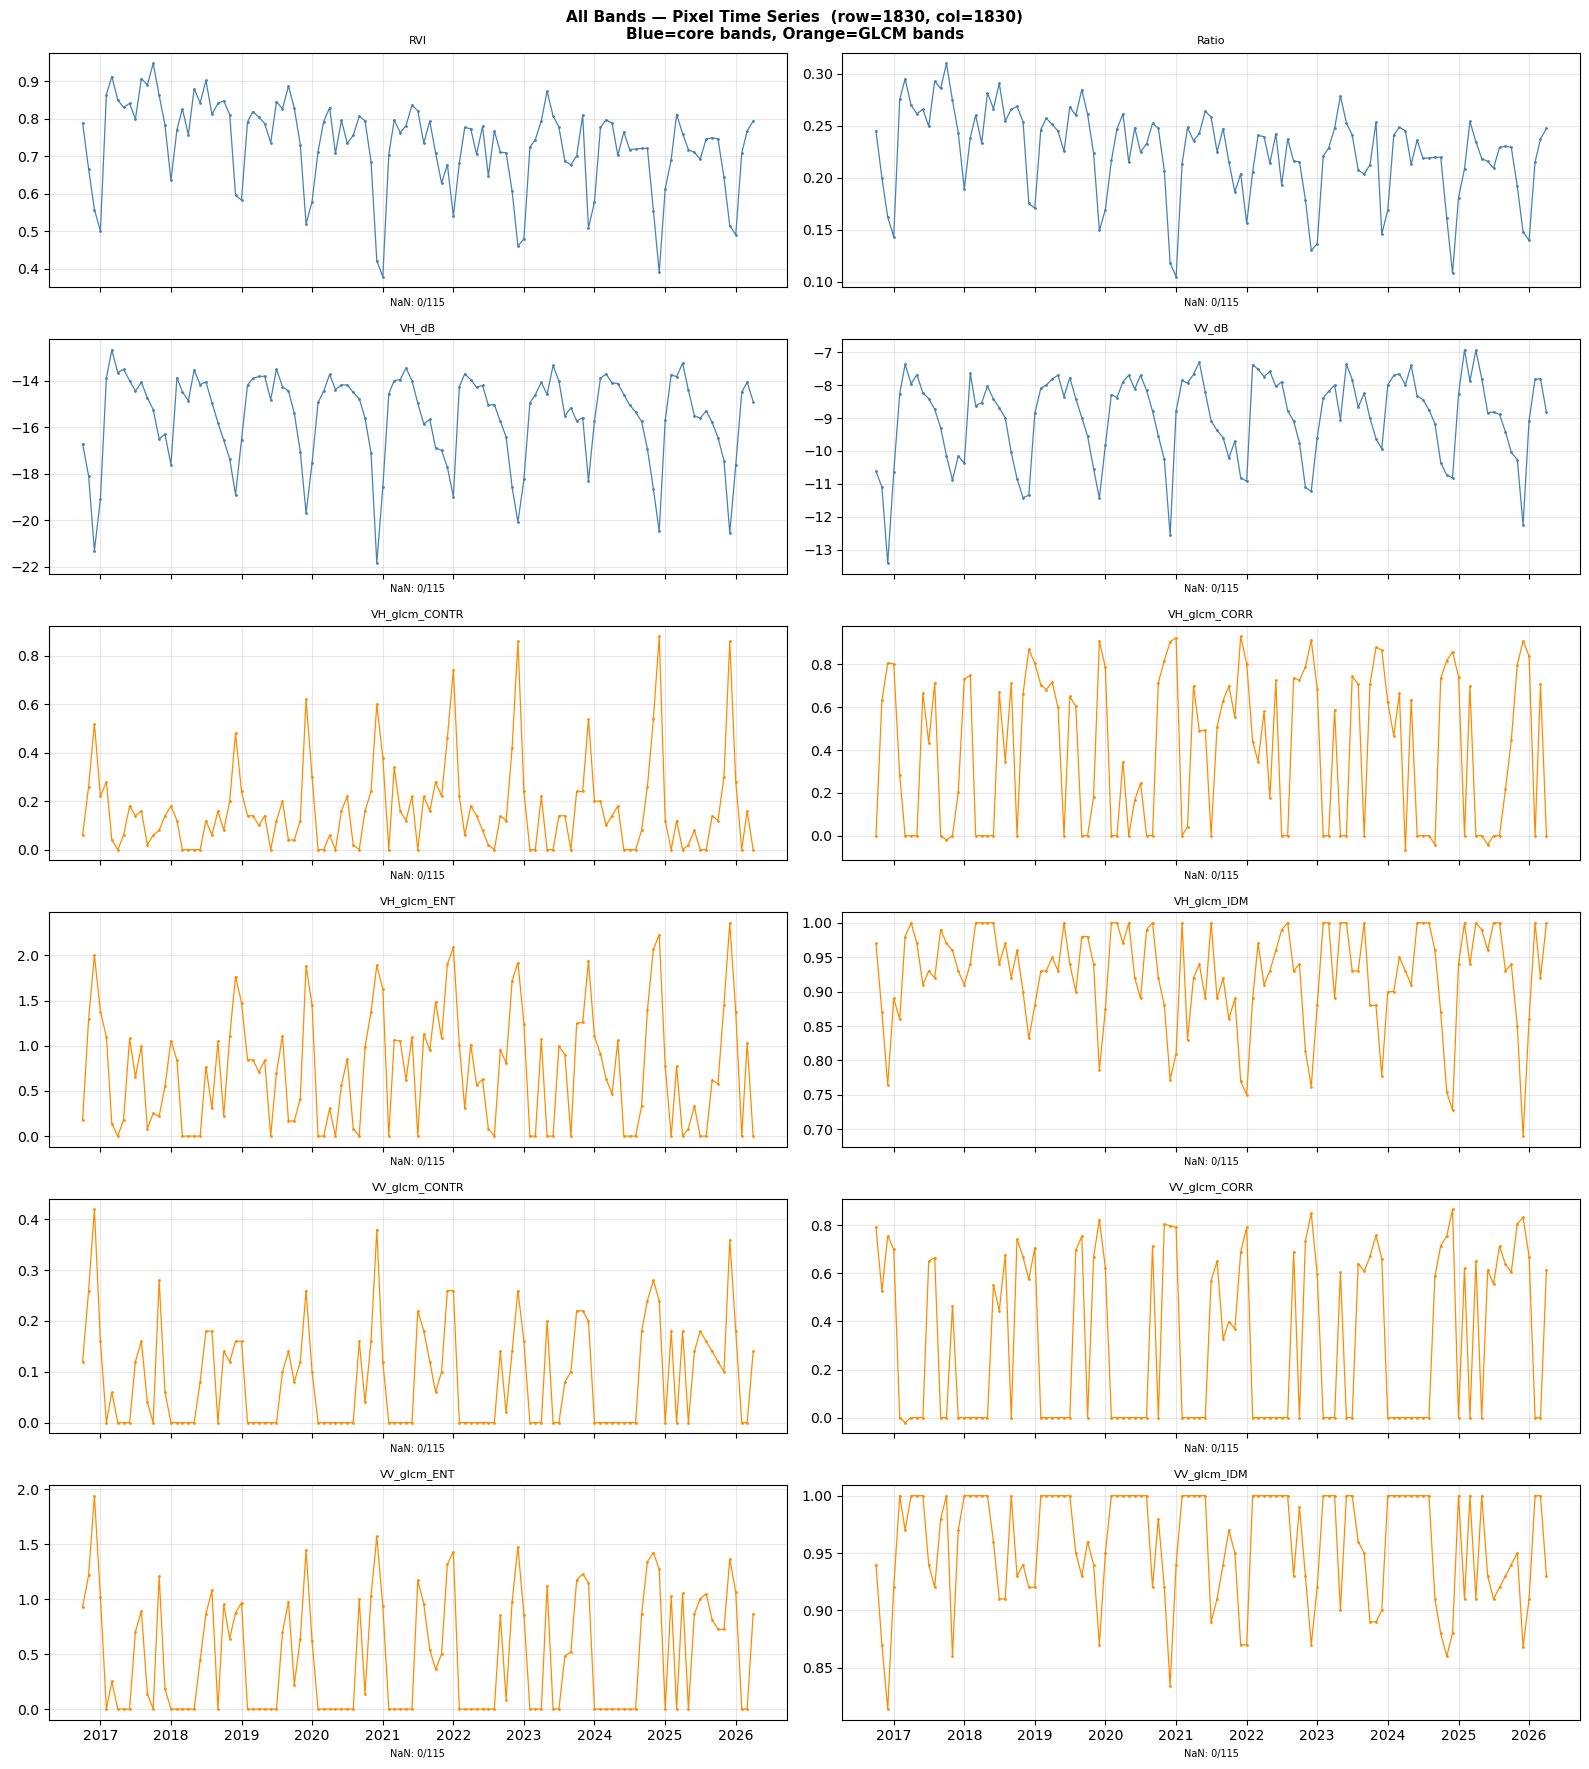

In [5]:
# =============================================================================
# Cell 06 — Single-pixel time series: all bands
# =============================================================================
if band_keys:
    ref_shape = z[band_keys[0]].shape  # (time, y, x)
    if SAMPLE_PIXEL is None:
        cy, cx = ref_shape[1] // 2, ref_shape[2] // 2
    else:
        cy, cx = SAMPLE_PIXEL
    print(f"INFO - Sampling pixel: row={cy}, col={cx}  (array shape: {ref_shape})")

    # Separate core vs GLCM for layout
    all_plot_bands = sorted(core_bands) + sorted(glcm_bands)
    n_bands = len(all_plot_bands)
    ncols = 2
    nrows = (n_bands + 1) // ncols

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(16, 3 * nrows),
                             sharex=True)
    axes_flat = axes.flatten() if n_bands > 1 else [axes]

    for i, k in enumerate(all_plot_bands):
        ax = axes_flat[i]
        ts = z[k][:, cy, cx].astype(np.float32)
        ts = np.where(ts < -9998.0, np.nan, ts)

        color = "steelblue" if k in core_bands else "darkorange"
        ax.plot(times, ts, color=color, linewidth=0.9, marker=".",
                markersize=2, label=k)
        ax.set_title(k, fontsize=8)
        ax.grid(True, alpha=0.3)

        n_nan = int(np.sum(np.isnan(ts)))
        ax.set_xlabel(f"NaN: {n_nan}/{len(ts)}", fontsize=7)

    # Hide unused subplots
    for j in range(n_bands, len(axes_flat)):
        axes_flat[j].set_visible(False)

    if hasattr(times, 'dtype') and np.issubdtype(times.dtype, np.datetime64):
        for ax in axes_flat[:n_bands]:
            pass
        axes_flat[min(n_bands - 1, len(axes_flat) - 1)].xaxis.set_major_formatter(
            mdates.DateFormatter("%Y"))

    fig.suptitle(
        f"All Bands — Pixel Time Series  (row={cy}, col={cx})\n"
        f"Blue=core bands, Orange=GLCM bands",
        fontsize=11, fontweight="bold"
    )
    plt.tight_layout()
    plt.show()

INFO - GLCM band: VH_glcm_CONTR
       Worst timestep: t=0  (2016-10-01 00:00:00)  NaN=0.1%
       Best  timestep: t=0   (2016-10-01 00:00:00)   NaN=0.1%


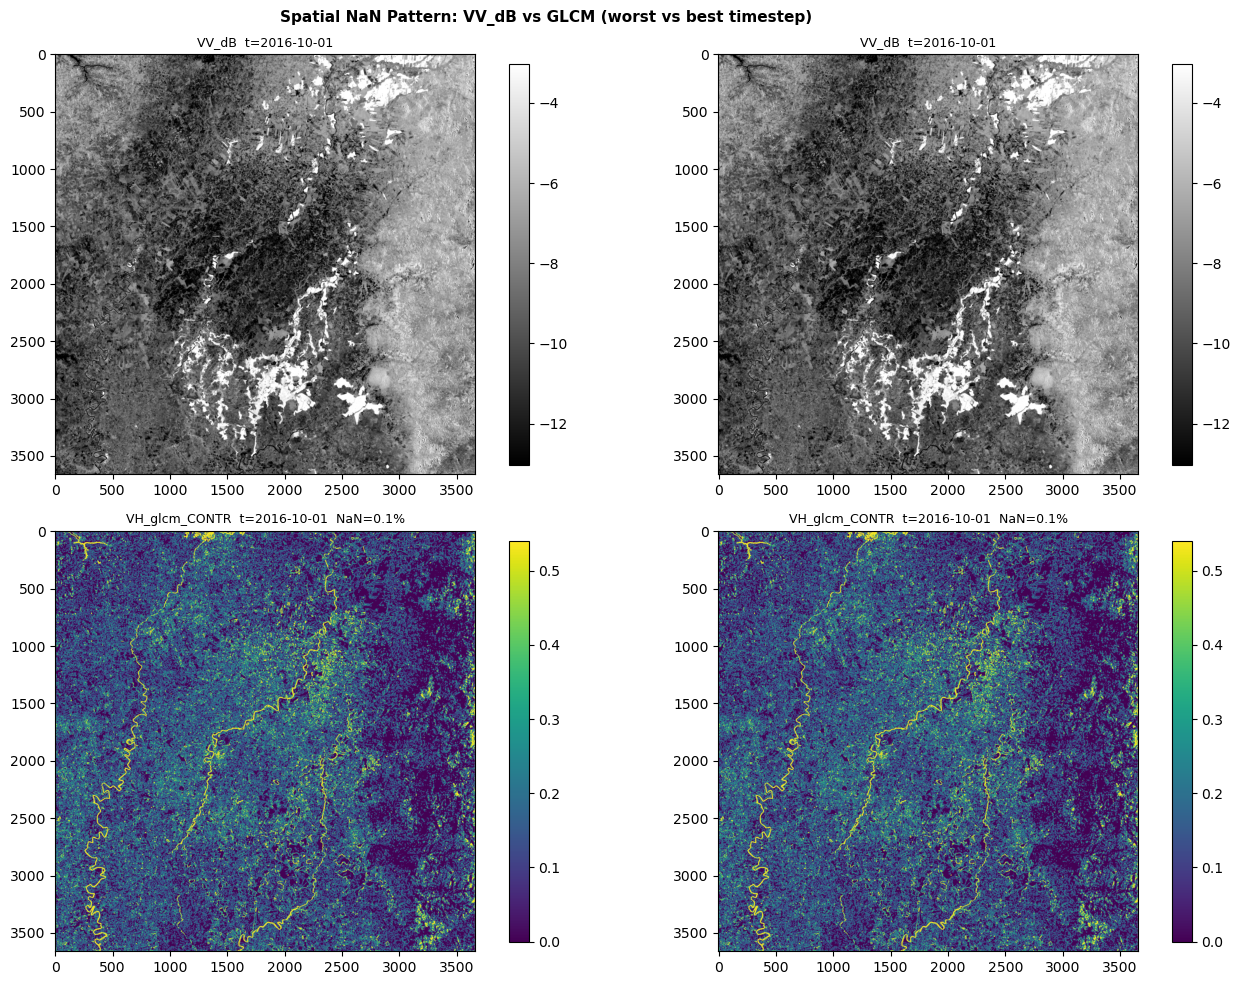

In [6]:
# =============================================================================
# Cell 07 — Spatial NaN map: compare VV_dB vs one GLCM band for a specific month
# Shows whether NaN is spatially correlated or random
# =============================================================================
import matplotlib.colors as mcolors

if not glcm_bands:
    print("INFO - No GLCM bands found. Skipping spatial NaN map.")
else:
    # Pick the time step with the most GLCM NaN
    glcm_ref = sorted(glcm_bands)[0]
    arr_glcm = z[glcm_ref][:].astype(np.float32)
    arr_glcm = np.where(arr_glcm < -9998.0, np.nan, arr_glcm)
    nan_per_t = np.mean(np.isnan(arr_glcm), axis=(1, 2))
    worst_t   = int(np.argmax(nan_per_t))
    best_t    = int(np.argmin(nan_per_t))

    print(f"INFO - GLCM band: {glcm_ref}")
    print(f"       Worst timestep: t={worst_t}  ({times[worst_t]})  NaN={nan_per_t[worst_t]*100:.1f}%")
    print(f"       Best  timestep: t={best_t}   ({times[best_t]})   NaN={nan_per_t[best_t]*100:.1f}%")

    arr_vv = z["VV_dB"][:].astype(np.float32)
    arr_vv = np.where(arr_vv < -9998.0, np.nan, arr_vv)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    for col_idx, t_idx in enumerate([worst_t, best_t]):
        t_label = str(times[t_idx])[:10]

        # VV_dB
        im0 = axes[0, col_idx].imshow(
            arr_vv[t_idx], cmap="gray",
            vmin=np.nanpercentile(arr_vv[t_idx], 2),
            vmax=np.nanpercentile(arr_vv[t_idx], 98)
        )
        axes[0, col_idx].set_title(f"VV_dB  t={t_label}", fontsize=9)
        plt.colorbar(im0, ax=axes[0, col_idx], fraction=0.03)

        # GLCM band
        glcm_slice = arr_glcm[t_idx]
        im1 = axes[1, col_idx].imshow(
            glcm_slice, cmap="viridis",
            vmin=np.nanpercentile(glcm_slice[~np.isnan(glcm_slice)], 2) if not np.all(np.isnan(glcm_slice)) else 0,
            vmax=np.nanpercentile(glcm_slice[~np.isnan(glcm_slice)], 98) if not np.all(np.isnan(glcm_slice)) else 1
        )
        axes[1, col_idx].set_title(f"{glcm_ref}  t={t_label}  NaN={nan_per_t[t_idx]*100:.1f}%", fontsize=9)
        plt.colorbar(im1, ax=axes[1, col_idx], fraction=0.03)

    fig.suptitle("Spatial NaN Pattern: VV_dB vs GLCM (worst vs best timestep)",
                 fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.show()

In [7]:
# =============================================================================
# Cell 08 — Diagnosis: check if GLCM NaN timestamps match months with
# fewer valid SAR acquisitions (low scene count in JSON catalog)
# =============================================================================
import json
from pathlib import Path

TILE_DIR = Path(r"D:\QGIS\s1grits-dataset\Ecuador_Dong_11tiles_ASCENDING_hARDCp\17MPU_ASCENDING")

# Load scene counts from JSON catalog files
scene_counts = {}
for jf in sorted(TILE_DIR.glob("*.json")):
    try:
        with open(jf) as f:
            data = json.load(f)
        month_str = jf.stem.split("_ASCENDING_")[-1]  # e.g. "2021-03"
        # Count scenes: look for common keys
        if isinstance(data, list):
            scene_counts[month_str] = len(data)
        elif isinstance(data, dict):
            scene_counts[month_str] = data.get("scene_count", data.get("n_scenes", len(data)))
    except Exception:
        pass

if scene_counts:
    sc_df = pd.DataFrame.from_dict(scene_counts, orient="index", columns=["scene_count"])
    sc_df.index = pd.to_datetime(sc_df.index)
    sc_df = sc_df.sort_index()

    print("=== Scene count per month (first 24) ===")
    print(sc_df.head(24).to_string())
    print(f"\nMonths with 0 scenes: {(sc_df['scene_count'] == 0).sum()}")
    print(f"Months with 1 scene:  {(sc_df['scene_count'] == 1).sum()}")
else:
    print("INFO - Could not parse scene counts from JSON files.")
    # Show first JSON to understand structure
    sample_json = next(TILE_DIR.glob("*.json"), None)
    if sample_json:
        with open(sample_json) as f:
            sample = json.load(f)
        print(f"Sample JSON ({sample_json.name}):")
        if isinstance(sample, dict):
            print(json.dumps({k: sample[k] for k in list(sample.keys())[:10]}, indent=2))
        elif isinstance(sample, list):
            print(f"  List of {len(sample)} items. First item keys: {list(sample[0].keys()) if sample else []}")

=== Scene count per month (first 24) ===
            scene_count
2016-10-01            9
2016-11-01            9
2016-12-01            9
2017-01-01            9
2017-02-01            9
2017-03-01            9
2017-04-01            9
2017-05-01            9
2017-06-01            9
2017-07-01            9
2017-08-01            9
2017-09-01            9
2017-10-01            9
2017-11-01            9
2017-12-01            9
2018-01-01            9
2018-02-01            9
2018-03-01            9
2018-04-01            9
2018-05-01            9
2018-06-01            9
2018-07-01            9
2018-08-01            9
2018-09-01            9

Months with 0 scenes: 0
Months with 1 scene:  0


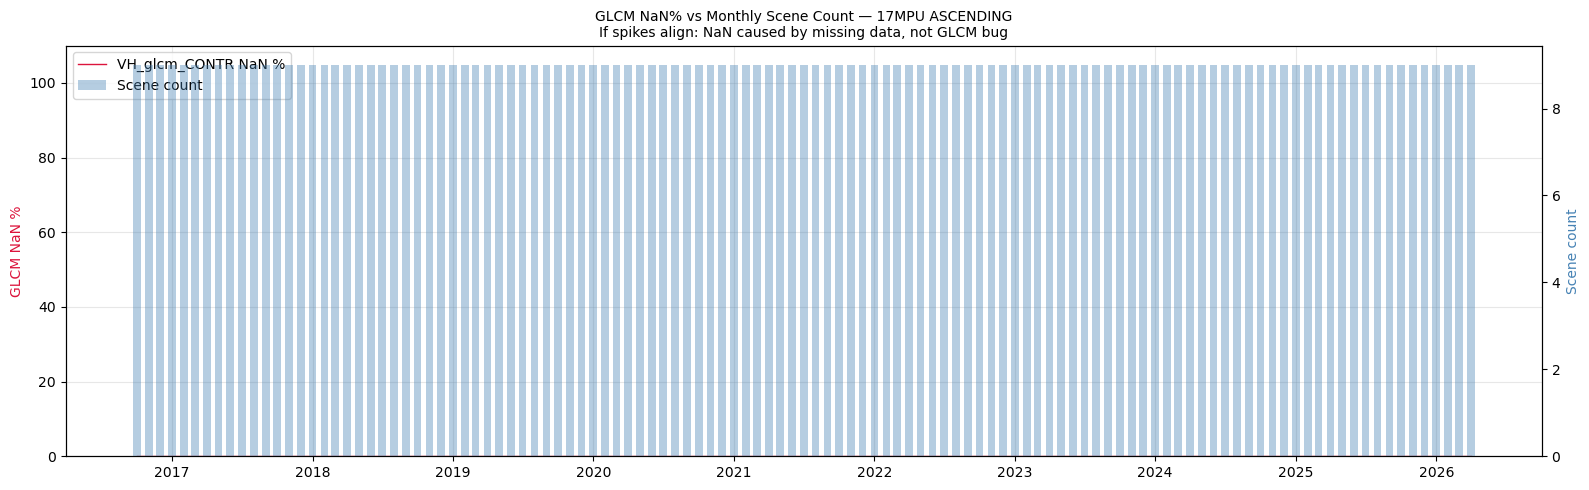

In [8]:
# =============================================================================
# Cell 09 — Overlay: GLCM NaN fraction vs scene count
# If GLCM NaN spikes align with low scene count months, the cause is
# insufficient data coverage (not a GLCM computation bug).
# =============================================================================
if glcm_bands and scene_counts:
    glcm_ref = sorted(glcm_bands)[0]
    arr_glcm = z[glcm_ref][:].astype(np.float32)
    arr_glcm = np.where(arr_glcm < -9998.0, np.nan, arr_glcm)
    nan_per_t = np.mean(np.isnan(arr_glcm), axis=(1, 2)) * 100

    fig, ax1 = plt.subplots(figsize=(16, 5))
    ax2 = ax1.twinx()

    ax1.plot(times, nan_per_t, color="crimson", linewidth=1.0,
             label=f"{glcm_ref} NaN %")
    ax1.set_ylabel("GLCM NaN %", color="crimson")
    ax1.set_ylim(0, 110)

    ax2.bar(sc_df.index, sc_df["scene_count"], width=20,
            color="steelblue", alpha=0.4, label="Scene count")
    ax2.set_ylabel("Scene count", color="steelblue")

    ax1.set_title(
        f"GLCM NaN% vs Monthly Scene Count — 17MPU ASCENDING\n"
        f"If spikes align: NaN caused by missing data, not GLCM bug",
        fontsize=10
    )
    ax1.grid(True, alpha=0.3)
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
    plt.tight_layout()
    plt.show()
elif glcm_bands:
    print("INFO - Scene count data not available. Cannot overlay.")
    print("       Run Cell 08 first to load scene counts.")